# Основная часть

## Импорты, seed и устройство


In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import random

from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms


def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

import os

os.makedirs("artifacts/figures", exist_ok=True)

Device: cpu


## Data

### Transforms

In [2]:
from torchvision import transforms

# базовый (для C1)
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# с аугментациями (для C2)
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# для ResNet (C3, C4)
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### STL10 Dataset

In [3]:
from torchvision.datasets import STL10
from torch.utils.data import random_split

DATA_DIR = "./data"

generator = torch.Generator().manual_seed(42)

dataset_base = STL10(
    root=DATA_DIR,
    split="train",
    download=True,
    transform=base_transform
)

dataset_aug = STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=aug_transform
)

dataset_resnet = STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=resnet_transform
)

train_size = int(0.8 * len(dataset_base))
val_size = len(dataset_base) - train_size

train_base, val_base = random_split(dataset_base, [train_size, val_size], generator=generator)
train_aug, val_aug = random_split(dataset_aug, [train_size, val_size], generator=generator)
train_resnet, val_resnet = random_split(dataset_resnet, [train_size, val_size], generator=generator)

### DataLoader

In [4]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader_base = DataLoader(train_base, batch_size=BATCH_SIZE, shuffle=True)
val_loader_base = DataLoader(val_base, batch_size=BATCH_SIZE)

train_loader_aug = DataLoader(train_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader_aug = DataLoader(val_aug, batch_size=BATCH_SIZE)

train_loader = train_loader_base

train_loader_resnet = DataLoader(train_resnet, batch_size=BATCH_SIZE, shuffle=True)
val_loader_resnet = DataLoader(val_resnet, batch_size=BATCH_SIZE)

### Sanity Check

Images shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])


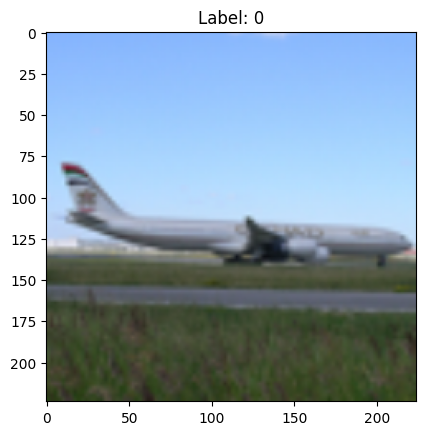

In [5]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

plt.imshow(images[0].permute(1,2,0))
plt.title(f"Label: {labels[0].item()}")
plt.show()

### Визуализация аугментаций

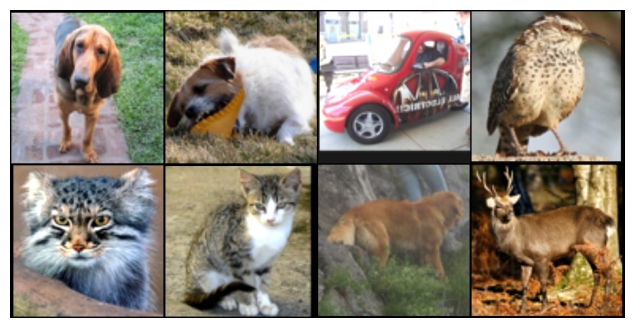

In [6]:
os.makedirs("artifacts/figures", exist_ok=True)

images, _ = next(iter(train_loader_aug))
grid = torchvision.utils.make_grid(images[:8], nrow=4)

plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")

plt.savefig("artifacts/figures/augmentations_preview.png")
plt.show()

### Augmentations Preview

In [7]:
from torchvision.datasets import STL10

raw_dataset = STL10(
    root="./data",
    split="train",
    download=False,
    transform=None 
)

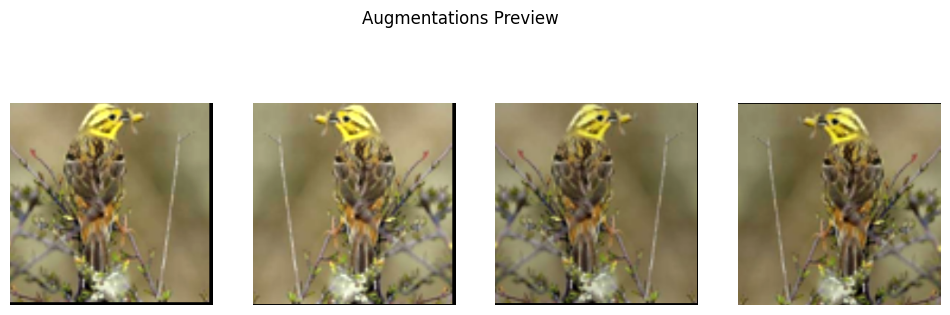

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(12,4))

img, _ = raw_dataset[0] 

for i in range(4):
    aug_img = aug_transform(img)
    axes[i].imshow(aug_img.permute(1,2,0))
    axes[i].axis("off")

plt.suptitle("Augmentations Preview")

plt.savefig("artifacts/figures/augmentations_preview.png")
plt.show()

## Models & Training Utils

### CNN модель (C1, C2)

In [9]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [10]:
def get_model_summary(model):
    return str(model.__class__.__name__)

In [11]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

def get_resnet18(num_classes=10, freeze_backbone=True):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

### Train / Eval функции

In [12]:
import torch.nn as nn

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        outputs = model(x)
        loss = criterion(outputs, y)

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

In [13]:
def run_experiment(model, train_loader, val_loader, epochs=5, lr=1e-3):
    model = model.to(device)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    best_val_acc = 0
    best_model_state = None

    history = {
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, device 
        )

        val_loss, val_acc = evaluate(
            model, val_loader, device  
        )

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: train_acc={train_acc:.3f}, val_acc={val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()

    return model, history, best_val_acc, best_model_state

# Эксперементы 

## Classification

### C1-C4

In [16]:
# C1
model_c1 = SimpleCNN()

model_c1, hist_c1, acc_c1, state_c1 = run_experiment(
    model_c1,
    train_loader_base,
    val_loader_base,
    lr=1e-3
)

# C2
model_c2 = SimpleCNN()

model_c2, hist_c2, acc_c2, state_c2 = run_experiment(
    model_c2,
    train_loader_aug,
    val_loader_aug,
    lr=1e-3
)

# C3
model_c3 = get_resnet18(freeze_backbone=True)

model_c3, hist_c3, acc_c3, state_c3 = run_experiment(
    model_c3,
    train_loader_resnet,
    val_loader_resnet,
    lr=1e-3
)

# C4
model_c4 = get_resnet18(freeze_backbone=False)

model_c4, hist_c4, acc_c4, state_c4 = run_experiment(
    model_c4,
    train_loader_resnet,
    val_loader_resnet,
    lr=1e-4
)

Epoch 1: train_acc=0.262, val_acc=0.335
Epoch 2: train_acc=0.427, val_acc=0.398
Epoch 3: train_acc=0.539, val_acc=0.419
Epoch 4: train_acc=0.674, val_acc=0.464
Epoch 5: train_acc=0.821, val_acc=0.464
Epoch 1: train_acc=0.198, val_acc=0.294
Epoch 2: train_acc=0.338, val_acc=0.366
Epoch 3: train_acc=0.398, val_acc=0.386
Epoch 4: train_acc=0.458, val_acc=0.456
Epoch 5: train_acc=0.520, val_acc=0.494
Epoch 1: train_acc=0.731, val_acc=0.901
Epoch 2: train_acc=0.925, val_acc=0.936
Epoch 3: train_acc=0.943, val_acc=0.947
Epoch 4: train_acc=0.950, val_acc=0.939
Epoch 5: train_acc=0.954, val_acc=0.948
Epoch 1: train_acc=0.850, val_acc=0.940
Epoch 2: train_acc=0.987, val_acc=0.952
Epoch 3: train_acc=1.000, val_acc=0.958
Epoch 4: train_acc=1.000, val_acc=0.953
Epoch 5: train_acc=1.000, val_acc=0.955


### Выбор лучшей модели 

In [17]:
results = {
    "C1": (acc_c1, state_c1),
    "C2": (acc_c2, state_c2),
    "C3": (acc_c3, state_c3),
    "C4": (acc_c4, state_c4),
}

best_exp = max(results, key=lambda x: results[x][0])
best_acc, best_state = results[best_exp]

print("Best experiment:", best_exp)
print("Best val accuracy:", best_acc)

Best experiment: C4
Best val accuracy: 0.958


### Сравнение C1–C4

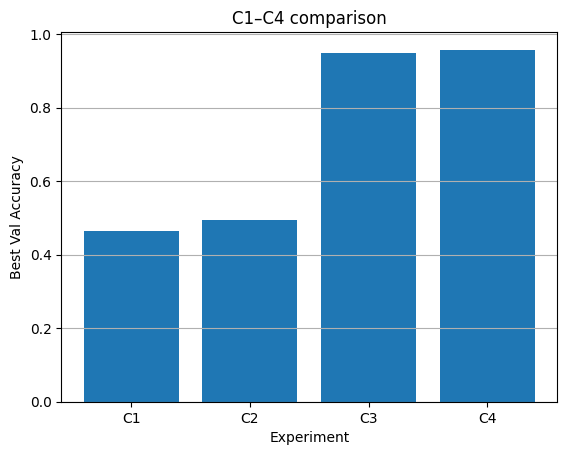

In [18]:
import matplotlib.pyplot as plt

plt.figure()

names = ["C1", "C2", "C3", "C4"]
values = [acc_c1, acc_c2, acc_c3, acc_c4]

plt.bar(names, values)

plt.xlabel("Experiment")
plt.ylabel("Best Val Accuracy")
plt.title("C1–C4 comparison")

plt.grid(axis="y")

plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

### График обучения

In [20]:
import os
os.makedirs("artifacts/figures", exist_ok=True)

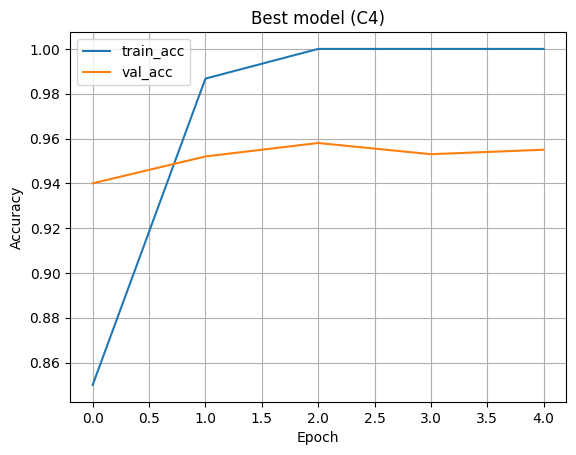

In [21]:
import matplotlib.pyplot as plt

hist_map = {
    "C1": hist_c1,
    "C2": hist_c2,
    "C3": hist_c3,
    "C4": hist_c4
}

best_hist = hist_map[best_exp]

plt.figure()

plt.plot(best_hist["train_acc"], label="train_acc")
plt.plot(best_hist["val_acc"], label="val_acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Best model ({best_exp})")

plt.legend()
plt.grid()

plt.savefig("artifacts/figures/classification_curves_best.png")
plt.show()

### TEST evaluation

In [23]:
from torchvision.datasets import STL10
from torch.utils.data import DataLoader

test_dataset = STL10(
    root=DATA_DIR,
    split="test",
    download=True,
    transform=resnet_transform  # тот же transform, что у лучшей модели
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [24]:
if best_exp in ["C1", "C2"]:
    best_model = SimpleCNN()
else:
    from torchvision.models import resnet18, ResNet18_Weights
    best_model = resnet18(weights=ResNet18_Weights.DEFAULT)
    best_model.fc = nn.Linear(best_model.fc.in_features, 10)

best_model.load_state_dict(best_state)
best_model = best_model.to(device)

test_loss, test_acc = evaluate(best_model, test_loader, device)

print("Test accuracy:", test_acc)

Test accuracy: 0.952625


### Сохранение модели

In [25]:
torch.save(best_state, "artifacts/best_classifier.pt")

### runs.csv

In [26]:
import pandas as pd
import os

os.makedirs("artifacts", exist_ok=True)

runs = [
    {
        "experiment_id": "C1",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "SimpleCNN",
        "optimizer": "Adam",
        "lr": 1e-3,
        "epochs_trained": 5,
        "best_val_accuracy": acc_c1,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": "baseline CNN"
    },
    {
        "experiment_id": "C2",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "SimpleCNN + aug",
        "optimizer": "Adam",
        "lr": 1e-3,
        "epochs_trained": 5,
        "best_val_accuracy": acc_c2,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": "augmentation"
    },
    {
        "experiment_id": "C3",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "ResNet18 head-only",
        "optimizer": "Adam",
        "lr": 1e-3,
        "epochs_trained": 5,
        "best_val_accuracy": acc_c3,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": "frozen backbone"
    },
    {
        "experiment_id": "C4",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "ResNet18 finetune",
        "optimizer": "Adam",
        "lr": 1e-4,
        "epochs_trained": 5,
        "best_val_accuracy": acc_c4,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": "layer4 + fc"
    },
]

df = pd.DataFrame(runs)

df.to_csv("artifacts/runs.csv", index=False)

df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN,Adam,0.0010,5,0.464,None,None,None,None,baseline CNN
1,C2,classification,STL10,42,SimpleCNN + aug,Adam,0.0010,5,0.494,None,None,None,None,augmentation
2,C3,classification,STL10,42,ResNet18 head-only,Adam,0.0010,5,0.948,None,None,None,None,frozen backbone
3,C4,classification,STL10,42,ResNet18 finetune,Adam,0.0001,5,0.958,None,None,None,None,layer4 + fc


## Segmentation

### ЧАСТЬ B - Dataset + Model

In [27]:
from torchvision.datasets import OxfordIIITPet
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision import transforms
from torch.utils.data import DataLoader

seg_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

seg_dataset = OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="segmentation",
    download=True,
    transform=seg_transform
)

seg_loader = DataLoader(seg_dataset, batch_size=4)

seg_model = deeplabv3_resnet50(
    weights=DeepLabV3_ResNet50_Weights.DEFAULT
).to(device)

seg_model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

### Маски + IoU

In [32]:
def preprocess_mask(mask):
    mask = torch.tensor(np.array(mask))
    mask = (mask == 1).float()  # foreground = pet
    mask = mask.unsqueeze(0).unsqueeze(0)
    mask = F.interpolate(mask, size=(224, 224), mode="nearest")
    mask = mask.squeeze().long()
    return mask


def compute_iou(pred, target):
    pred = pred > 0
    target = target > 0

    intersection = (pred & target).sum().item()
    union = (pred | target).sum().item()

    return intersection / union if union > 0 else 0

### Inference + IoU + Visualization

Mean IoU V1: 0.5798270188470349
Mean IoU V2: 0.5802122678747427
Foreground = pet (class > 0)


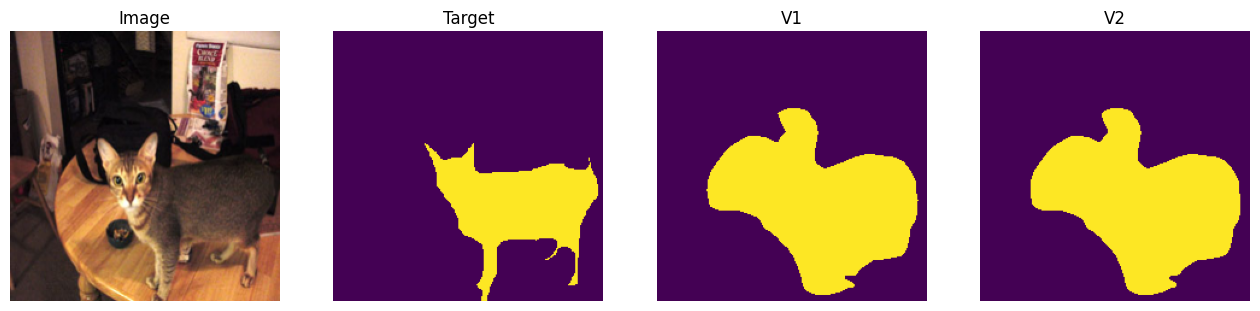

In [31]:
os.makedirs("artifacts/figures", exist_ok=True)

# ===== IoU для V1 и V2 =====
ious_v1 = []
ious_v2 = []

for i in range(10):
    image, target = seg_dataset[i]
    target = preprocess_mask(target)

    with torch.no_grad():
        output = seg_model(image.unsqueeze(0).to(device))["out"]

    pred_mask = torch.argmax(output.squeeze(), dim=0).cpu()

    # --- V1 ---
    pred_v1 = (pred_mask != 0).long()

    # --- V2 (сглаживание) ---
    pred_float = pred_v1.float().unsqueeze(0).unsqueeze(0)
    pred_smooth = F.avg_pool2d(pred_float, kernel_size=5, stride=1, padding=2)
    pred_v2 = (pred_smooth > 0.5).long().squeeze()

    ious_v1.append(compute_iou(pred_v1, target))
    ious_v2.append(compute_iou(pred_v2, target))

print("Mean IoU V1:", sum(ious_v1)/len(ious_v1))
print("Mean IoU V2:", sum(ious_v2)/len(ious_v2))
print("Foreground = pet (class > 0)")

# ===== Визуализация =====
image, target = seg_dataset[0]
target = preprocess_mask(target)

with torch.no_grad():
    output = seg_model(image.unsqueeze(0).to(device))["out"]

pred_mask = torch.argmax(output.squeeze(), dim=0).cpu()

pred_v1 = (pred_mask != 0).long()

pred_float = pred_v1.float().unsqueeze(0).unsqueeze(0)
pred_smooth = F.avg_pool2d(pred_float, kernel_size=5, stride=1, padding=2)
pred_v2 = (pred_smooth > 0.5).long().squeeze()

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(target)
plt.title("Target")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_v1)
plt.title("V1")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred_v2)
plt.title("V2")
plt.axis("off")

plt.savefig("artifacts/figures/segmentation_examples.png")
plt.show()